# Load Libraries




In [37]:
%load_ext autoreload
%autoreload 2


import numpy as np
import pandas as pd
import sys
import scipy.io
import os
import sys
from pathlib import Path
import pickle
from gc import collect
from glob import glob
from datetime import datetime
import traceback
from time import sleep
import matplotlib.dates as mdates


#Important!! Make sure your current directory is the MHDTurbPy folder!
os.chdir("/Users/turbulator/work/MHDTurbPy")






""" Import manual functions """

sys.path.insert(1, os.path.join(os.getcwd(), 'functions'))

import TurbPy as turb
import general_functions as func
import Figures as figs
from   SEA import SEA
import three_D_funcs as threeD
import download_data as download


# Better figures
# Prepend the directory where LaTeX is installed
os.environ["PATH"] = "/usr/local/texlive/2024/bin/universal-darwin:" + os.environ["PATH"]

from matplotlib import pyplot as plt
plt.style.use(['science', 'scatter'])
plt.rcParams['text.usetex'] = True
from joblib import Parallel, delayed


import colormaps as cmaps
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


/Users/turbulator/work/MHDTurbPy/pyspedas/pyspedas/__init__.py
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Download data

First let's download some ScaM data with the noise_removal set to False

In [14]:

#User defined parameters 

cdf_lib_path            = '/Applications/cdf/cdf/lib'            # You will need to read cdf files. You have to specify the path

""" At this point you NEED credentials for function to work. This is because of the ephemeris data! Let me know if this doesnt work"""


credentials             =      { 'psp':{
                                           'fields': {'username': None, 'password': None},
                                           'sweap' : {'username': None, 'password': None}}}



settings                =  {
    
                    ###____How to handle data ____###
    
                            'Data_path'              : '/Users/turbulator/work/Data/',  # Path were pyspedas downloads data
                            'save_destination'       : '/Users/turbulator/work/MHDTurbPy/examples/noise/',#'/Users/turbulator/work/MHDTurbPy/examples/',
                            'use_local_data'         :  False,                        # Whether to donwload data(again) or use local data
                            'overwrite_files'        :  1,                            # In case you want to re-do analysis for existing files!
                            'save_all'               :  True,                         # If false it will only keep derived quants. Not timeseries
                            'addit_time_around'      :  1,                            # When loading at first it will return [start_time -addit_time_around [h], end_time + addit_time_around [h]]. The data are cut to the right dates later
                            'gap_time_threshold'     :  5 ,                           # Threshold for large gaps (units of seconds)
    
                       ###____Basics for the intervals ____###   
                            'sc'                     : 'PSP',                         # Choices ['PSP', SOLO, 'HELIOS_A', 'HELIOS_B', 'WIND']
                            'in_rtn'                 :  1,                          # RTN or spacecraft frame ( We will usually use RTN)
                            'multiple_intervals'     :  False,                         # If you only want to check one interval
    
                        ###____Only matters if 'Only_1_interval' ==False. It will essentially download adjacent intervals overlaping by 'Step'____###
                            'duration'               : '4H',                         # Duration of interval
                            'Step'                   : '210min',                     # Move starting point by step 
    
                            'start_date'             : '2024-12-27 05:00' ,
                            'end_date'               : '2024-12-27 06:00' ,
                            'must_have_qtn'          :  1,                            # Dont consider interval if no qtn data. Only matters for PSP & SOLO
                            'Max_par_missing'        :  30,                           # Maximum fraction of missing particle data allowed
                            'particle_mode'          : '9th_perih_cut',               # Only for PSP: either: 'spc', 'span', '9th_perih_cut'
                            'max_PSP_dist'           : 0.6,                           # Maximum PSP distance to consider [au]
                            'part_resol'             : 1000,                           # Max resol of plasma data                [ms]
                            'MAG_resol'              : 1,                             # Max resol og magnetic field data        [ms] [<230: Full resol mag data, >230 : 4_sa_per_sec dataset]
                            'upsample_low_freq_ts'   : False,                         # False: Whether to downsample mag data (after applying low-pass filter to make them match the cadence of velocity field data 

                    

                            'cut_in_small_windows'   : {
                                                        'flag'    : False, 
                                                        'njobs'   : 10,
                                                        'Step'    : '5s',          # Cuts each  larger interval in small windows. To avoid loading data again and again (Too slow)
                                                        'duration': '30s'},  
    
                            'Mag_SCAM_PSP': {'flag'         :  True,               # Set False to download fluxgate data
                                             'noise_flag'   :  False,
                                             'noise_removal': {
                                                                'window_size'         : 2**15,
                                                                'avg_length'          : 1,
                                                                'power_threshold'     : 3.0,
                                                                'freq_min'            : 10.0 # in Hz
                                                              }},

                            'sc_pot'     :{
                                            'flag'                 : False,
                                            'fit_interval_minutes' : '10min',
                                            'est_roll_med'         :  False,
                                            'roll_wind_minutes'    : '4min',
                                            'n_sigma_outliers'     : 3
                                          },
    
                            'E_field'    :  {'flag'                 : False,
                                             'cadence_seconds'      : 6,
                                             'fit_interval_minutes' : 4,
                                             'stride_minutes'       : 0.1,
                                             'min_correlation'      : 0.8
                                             },
    
                            'coherence_analysis' : {'flag'                  : False,
                                                    'method'                : {'min_var': ['B'], 
                                                                               'TN_only': ['B', 'E']},
                                                    'nv'                    : 8,
                                                    'alpha'                 : 3,
                                                    'per_thresh'            : 80,
                                                    'par_thresh'            : 10,
                                                    'coh_th'                : 0.7,
                                                    'num_efoldings'         : 3,
                                                    'njobs'                 : 10,
                                                    'est_mod'               : True,
                                                    'estimate_local_V'      : False,
                                                    
                                                    'do_coherence_analysis' : True,
                                                    'estimate_PSDs'         : True,
                                                    'estimate_coh_coeffs'   : True,
                                                    'estimate_comp'         : True,
                                                    'return_coeffs'         : False,
                                                    'est_sfuncs'            : False,
                                                    'max_qorder'            : 8
                            },
    
                            'PSDs'               : {'flag'                  : False},
                            'struc_funcs'        : {'flag'                  : False},
    
                            'npt_struc_funcs'    : {'flag'                  : False,
                                                    'five_points_sfunc'     : True,
                                                    'return_Bmod'           : True,
                                                    'dt_step'               : 0.25,
                                                    'est_sfuncs'            : False,
                                                    'max_qorder'            : 8
                            },

                     ###____Additional diagnostics ____###  
    
                            'estimate_derived_param' : True,
                            'rol_window'             : '60min',                          # When estimating fluctuations, size of window (centered around -w/2 -w/2
                            'apply_hampel'           : False,                         # Use hampelfilter to despike plasma data
                            'hampel_params'          : {'w':200, 'std':3},
                                                                                      # True : Upsample velocity field data
    
                            'estimate_psd_b'         : 0,                             # Estimate magentic field powes spectral density (keep false)
                            'estimate_psd_v'         : 0,                             # Estimate velocity field powes spectral density (keep false)
                            'est_PSD_components'     : 0,
                            'smooth_psd'             : False,
                            'Big_Gaps'               :{
                                                        'E_big_gaps'      : 10,
                                                        'SC_pot_big_gaps' : 10,
                                                        'Mag_big_gaps'    : 500,
                                                        'Par_big_gaps'    : 500,           # A file will be returned where gaps in the timeseries (larger than
                                                        'QTN_big_gaps'    : 10,          # those specified here [s]) are shown. This will enable the user to 
                                                                                       # omit the gappy data later
                                                        }                           
                            } 


# You can chnage those if more data are needed. Check /downloading_helpers/ PSP or SOLO to find default data to be downloaded
if settings['sc'] == "PSP":
    
    if settings['in_rtn']:
        vars_2_downnload = {
                            'mag'    : None, 
                            'span'   : None,
                            'span-a' : None,
                            'spc'    : None, 
                            'qtn'    : None,
                            'E_field': settings['E_field']['flag'],
                            'sc_pot' : settings['sc_pot']['flag'],
                            'ephem'  : None}
    else:
        vars_2_downnload        = {  
                                    'mag'     : ['B_SC'],
                                    'span'    : ['DENS',  'VEL_SC', 'TEMP' , 'SUN_DIST'],
                                    'span-a'  : None,
                                    'spc'     : ['np_moment', 'wp_moment', 'vp_moment_SC','sc_pos_HCI'],
                                    'qtn'     : ['electron_density'],
            
                                    'E_field' : settings['E_field']['flag'],
                                    'sc_pot'  : settings['sc_pot']['flag'],
            
            
                                    'ephem'   : None}      

elif settings['sc'] == "SOLO":
    vars_2_downnload = {
                        'mag'    : None,
                        'swa'    : None, 
                        'rpw'    : None, # Default is 'bia-density-10-seconds', but  'bia-density' is also available and probaly interesting
                        'ephem'  : None} 
else:
    
    print('Not ready yet!')
    



generated_interval_list = download.generate_intervals(settings['start_date'],
                                                      settings['end_date'], 
                                                      settings['multiple_intervals'],
                                                      data_path = settings['Data_path'],
                                                      settings  = settings)

# Save download files in specified dir
os.chdir(settings['Data_path'])

# Call function
Parallel(n_jobs=1)(delayed(download.download_files)(
                                                    jj, 
                                                    generated_interval_list, 
                                                    settings, 
                                                    vars_2_downnload, 
                                                    cdf_lib_path, 
                                                    credentials, 
                                                    Path(settings['save_destination']).joinpath(settings['sc'])) for jj in range( len(generated_interval_list)))


21-May-25 15:19:17: Generating only one interval based on the provided start and end times.
21-May-25 15:19:17: Start Time: 2024-12-27 05:00:00
21-May-25 15:19:17: End Time: 2024-12-27 06:00:00
21-May-25 15:19:17: Considering a single interval spanning: 2024-12-27 05:00:00 to 2024-12-27 06:00:00
21-May-25 15:19:17: Creating new folder  /Users/turbulator/work/MHDTurbPy/examples/noise/PSP/2024-12-27_05-00-00_2024-12-27_06-00-00_sc_0
21-May-25 15:19:17: File is current: psp_data/fields/l1/ephem_spp_rtn/2024/12/spp_fld_l1_ephem_spp_rtn_20241227_v01.cdf
NoneType: None
21-May-25 15:19:17: Downloading remote index: https://sprg.ssl.berkeley.edu/data/spp/data/sci/fields/l2/mag_RTN/2024/12/
21-May-25 15:19:17: Downloading https://sprg.ssl.berkeley.edu/data/spp/data/sci/fields/l2/mag_RTN/2024/12/psp_fld_l2_mag_RTN_2024122700_v02.cdf to psp_data/fields/l2/mag_RTN/2024/12/psp_fld_l2_mag_RTN_2024122700_v02.cdf


Working on PSP data
['electron_density', 'electron_core_temperature']
Attempting to load Orlando's QTN data...
Failed to load Orlando's QTN data: 'orlandos_QTN'. Using alternative method...
Attempting to load Orlando's QTN data...
FLAG QTN QTN
[]
Passed Dist & QTN thresholds
Working on fluxgate mag data
Using private mag data
Using RTN frame mag data.


21-May-25 15:19:20: Download complete: psp_data/fields/l2/mag_RTN/2024/12/psp_fld_l2_mag_RTN_2024122700_v02.cdf
21-May-25 15:19:20: Downloading https://sprg.ssl.berkeley.edu/data/spp/data/sci/fields/l2/mag_RTN/2024/12/psp_fld_l2_mag_RTN_2024122706_v02.cdf to psp_data/fields/l2/mag_RTN/2024/12/psp_fld_l2_mag_RTN_2024122706_v02.cdf
21-May-25 15:19:22: Download complete: psp_data/fields/l2/mag_RTN/2024/12/psp_fld_l2_mag_RTN_2024122706_v02.cdf
21-May-25 15:19:28: Downloading remote index: https://sprg.ssl.berkeley.edu/data/spp/data/sci/fields/l2/mag_RTN/2024/12/
21-May-25 15:19:28: File is current: psp_data/fields/l2/mag_RTN/2024/12/psp_fld_l2_mag_RTN_2024122700_v02.cdf
21-May-25 15:19:28: File is current: psp_data/fields/l2/mag_RTN/2024/12/psp_fld_l2_mag_RTN_2024122706_v02.cdf


[]


21-May-25 15:19:32: Downloading remote index: http://sweap.cfa.harvard.edu/data/sci/sweap/spi/L3/spi_sf00/2024/12/


...

21-May-25 15:19:33: File is current: psp_data/sweap/spi/L3/spi_sf00/2024/12/psp_swp_spi_sf00_L3_mom_20241227_v00.cdf
21-May-25 15:19:33: Downloading http://sweap.cfa.harvard.edu/data/sci/sweap/spi/L3/spi_sf00/2024/12/psp_swp_spi_sf00_L3_mom_20241227_v04.cdf to psp_data/sweap/spi/L3/spi_sf00/2024/12/psp_swp_spi_sf00_L3_mom_20241227_v04.cdf
21-May-25 15:19:53: Download complete: psp_data/sweap/spi/L3/spi_sf00/2024/12/psp_swp_spi_sf00_L3_mom_20241227_v04.cdf
21-May-25 15:19:53: Downloading remote index: http://sweap.cfa.harvard.edu/data/sci/sweap/spc/L3/2024/12/


Spc Variables ['np_moment', 'wp_moment', 'vp_moment_RTN', 'sc_pos_HCI', 'carr_longitude']
Using LEVEL=L3 (unpublished)


21-May-25 15:19:53: File is current: psp_data/sweap/spc/L3/2024/12/spp_swp_spc_l3i_20241227_v00.cdf
21-May-25 15:19:53: File is current: psp_data/sweap/spc/L3/2024/12/spp_swp_spc_l3i_20241227_v01.cdf
21-May-25 15:19:54: File is current: psp_data/sweap/spc/L3/2024/12/spp_swp_spc_l3i_20241227_v02.cdf
21-May-25 15:19:54: Downloading http://sweap.cfa.harvard.edu/data/sci/sweap/spc/L3/2024/12/spp_swp_spc_l3i_20241227_v03.cdf to psp_data/sweap/spc/L3/2024/12/spp_swp_spc_l3i_20241227_v03.cdf
21-May-25 15:20:27: Download complete: psp_data/sweap/spc/L3/2024/12/spp_swp_spc_l3i_20241227_v03.cdf


No na
0 out of 1 finished


[None]

# Load data

In [15]:
#  User defined parameters
sc          = 'PSP'
which_int   = 1
load_path   =   f'/Users/turbulator//work/MHDTurbPy/examples/noise/{sc}'


# Locate the downloaded files
finnames      = func.load_files(load_path, 'final.pkl')
gennames      = func.load_files(load_path, 'general.pkl')
signames      = func.load_files(load_path, 'sig_c_sig_r.pkl')
maggaps       = func.load_files(load_path, 'mag_gaps.pkl')
qtngaps       = func.load_files(load_path, 'qtn_gaps.pkl')
pargaps       = func.load_files(load_path, 'par_gaps.pkl')
sc_pot        = func.load_files(load_path, 'sc_pot_gaps.pkl')


#Load the filed
fin         = pd.read_pickle(finnames[which_int])
gen         = pd.read_pickle(gennames[which_int])
sig         = pd.read_pickle(signames[which_int])
mag_gaps    = pd.read_pickle(maggaps[which_int])
qtn_gaps    = pd.read_pickle(qtngaps[which_int])
par_gaps    = pd.read_pickle(pargaps[which_int])
sc_pot_gaps = pd.read_pickle(sc_pot[which_int])

finnames[which_int]

/Users/turbulator/work/MHDTurbPy/examples/noise/PSP/*/final.pkl
/Users/turbulator/work/MHDTurbPy/examples/noise/PSP/*/general.pkl
/Users/turbulator/work/MHDTurbPy/examples/noise/PSP/*/sig_c_sig_r.pkl
/Users/turbulator/work/MHDTurbPy/examples/noise/PSP/*/mag_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/noise/PSP/*/qtn_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/noise/PSP/*/par_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/noise/PSP/*/sc_pot_gaps.pkl


'/Users/turbulator/work/MHDTurbPy/examples/noise/PSP/2024-12-27_05-00-00_2024-12-27_06-00-00_sc_0/final.pkl'

# Remove noise

In [16]:
# Define B dataframe 
B                   = fin['Mag']['B_resampled']
signal_contaminated = B.Bt.values

# Create a copy
cleaned_B = B.copy()

# Apply noise removal filter
for key in B.keys():
    
    signal_noise_removed = turb.remove_wheel_noise(B[key].values,
                                                   1/func.find_cadence(B), 
                                                   window_size      = 2**15, 
                                                   avg_length       = 1,
                                                   power_threshold  = 6.0,
                                                   freq_min         = 10.0, 
                                                   hampel_wind      = 51,
                                                   hampel_thresh    = 3.5)

    
   
    #replace with clean data
    cleaned_B[key] = signal_noise_removed


(16385,) (16385, 75)
(16385,) (16385, 75)
(16385,) (16385, 75)


#  Using FFT

21-May-25 15:20:50: /opt/homebrew/anaconda3/envs/numba/lib/python3.10/site-packages/matplotlib/dviread.py:1048: ResourceWarning: unclosed file <_io.BufferedWriter name=82>
  self._proc = self._new_proc()

21-May-25 15:20:50: /opt/homebrew/anaconda3/envs/numba/lib/python3.10/site-packages/matplotlib/dviread.py:1048: ResourceWarning: unclosed file <_io.BufferedReader name=83>
  self._proc = self._new_proc()



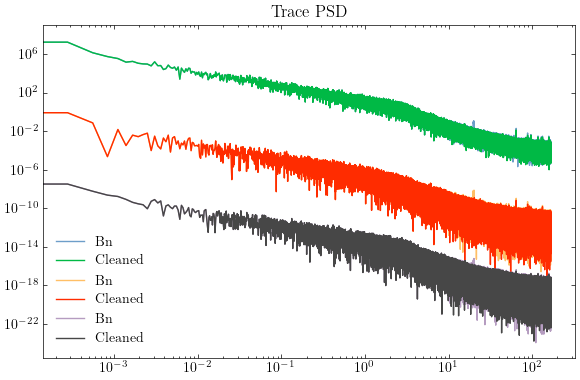

In [17]:

P_raw          = turb.TracePSD(B.Br.values, B.Bt.values, B.Bn.values, func.find_cadence(B), return_components=True)
P_cln          = turb.TracePSD(cleaned_B.Br.values, cleaned_B.Bt.values, cleaned_B.Bn.values, func.find_cadence(cleaned_B), return_components=True)
#f_noise, P_n   = psd(extracted_noise)

plt.figure(figsize=(6,4))

keys = list(B.keys())
           
for jj in range(len(keys)):
    plt.loglog(P_raw[0],  (10000000**-jj)*P_raw[1+jj],  alpha=.6, ms=0, ls='-', label=key)
    plt.loglog(P_cln[0],  (10000000**-jj)*P_cln[1+jj],  label='Cleaned',ms=0, ls='-')
#plt.loglog(f_noise, P_n,   label='Extracted noise', ls='--',ms=0)
#plt.xlim(0.8, 100)
#plt.ylim(1e-4, 1e3)
# plt.xlabel(r'$f_{\mathrm sc}\,[\mathrm{Hz}]$')
# plt.ylabel(r'$P_B\;[\mathrm{arb.\;u}/\mathrm{Hz}]$')
plt.legend()
plt.title('Trace PSD')

plt.tight_layout()
plt.show()

# 

# Plot Trace PSD 

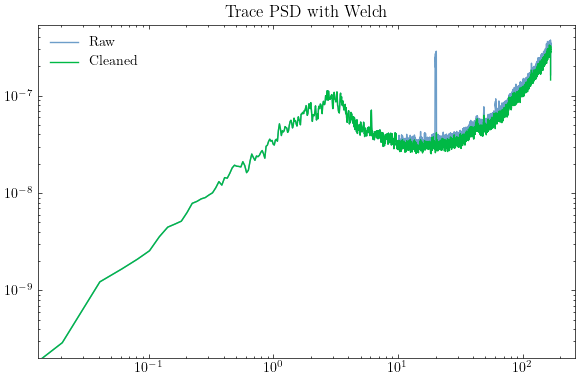

In [19]:
dt = func.find_cadence(B)


f_raw,  P_raw  = turb.Trace_psd_Hann(B, dt)
f_cln,  P_cln  = turb.Trace_psd_Hann(cleaned_B, dt)
#f_noise, P_n   = psd(extracted_noise)

plt.figure(figsize=(6,4))
plt.loglog(f_raw,  P_raw*f_raw**(8/3),  label='Raw', alpha=.6, ms=0, ls='-')
plt.loglog(f_cln,  P_cln*f_raw**(8/3),  label='Cleaned',ms=0, ls='-')
#plt.loglog(f_noise, P_n,   label='Extracted noise', ls='--',ms=0)
#plt.xlim(0.8, 100)
#plt.ylim(1e-4, 1e3)
# plt.xlabel(r'$f_{\mathrm sc}\,[\mathrm{Hz}]$')
# plt.ylabel(r'$P_B\;[\mathrm{arb.\;u}/\mathrm{Hz}]$')
plt.legend()
plt.title('Trace PSD with Welch')
plt.tight_layout()
plt.show()

# Wavelets?

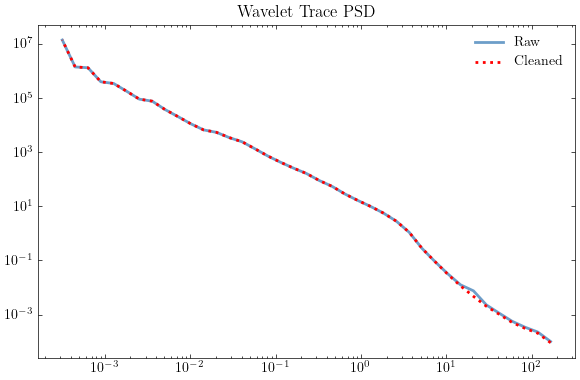

In [36]:
tr_or    = turb.trace_PSD_wavelet(B.Br.values, B.Bt.values, B.Bn.values, func.find_cadence(B))
tr_clean = turb.trace_PSD_wavelet(cleaned_B.Br.values, cleaned_B.Bt.values, cleaned_B.Bn.values, func.find_cadence(B))



plt.figure(figsize=(6,4))
plt.loglog(tr_or[-3], tr_or[-2],  label='Raw', alpha=.6, ms=0, lw=2, ls='-')
plt.loglog(tr_clean[-3], tr_clean[-2],  label='Cleaned',ms=0, lw=2, ls=':', c='r')


plt.legend()
plt.title('Wavelet Trace PSD')
plt.tight_layout()
plt.show()

# Compare the clean and filtered timeseries

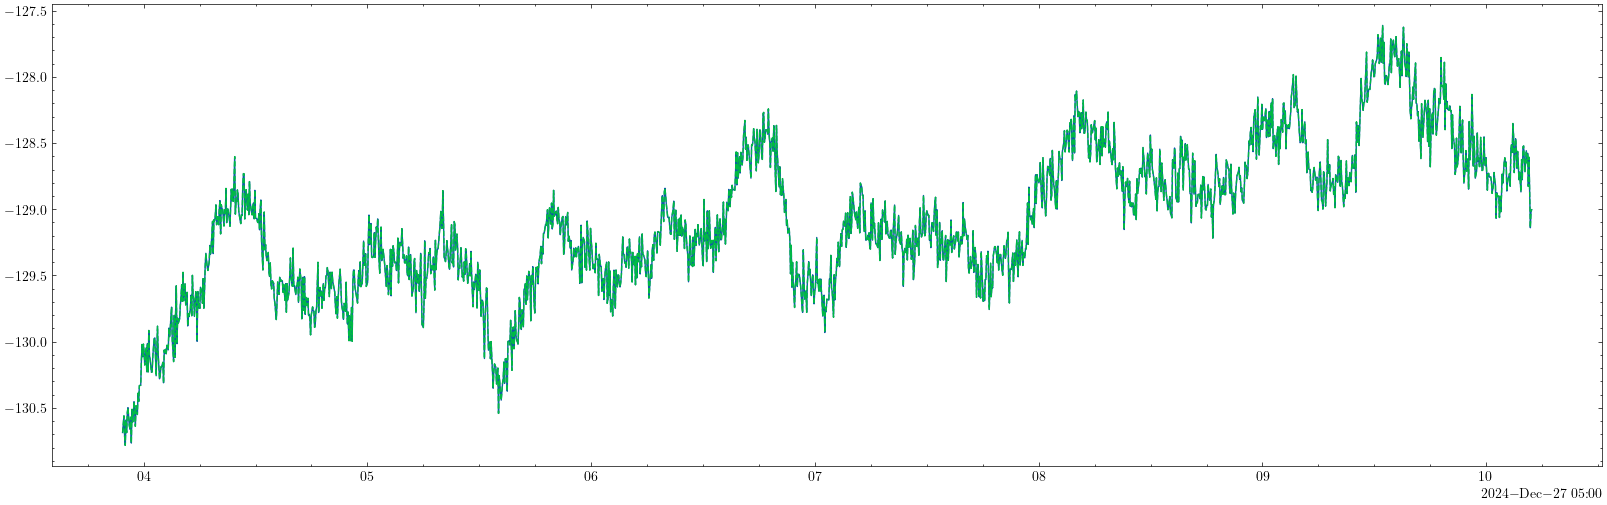

In [20]:



N,M = 1000, 3100


plt.figure(figsize=(20,6))
plt.plot(B.Br[N:M],ms=0, ls='-')
plt.plot(cleaned_B.Br[N:M],ms=0, ls='--')